# **Machine Learning for Evapotranspiration: A Random Forest Baseline, Done Carefully**

Train a random forest to predict latent heat flux from meteorology and vegetation, evaluate it the right way, and ask whether it has learned any physics.

## **Learning objectives**

By the end of this tutorial you will be able to:

- Set up a machine-learning problem for a hydrologic flux: features, target, and a time-based train/test split.
- Train and evaluate a random forest with R$^2$, RMSE, and Nash-Sutcliffe efficiency.
- Interpret the model with permutation importance and partial dependence.
- Test whether the model respects physical limits and how it behaves outside the training range.

**Before you start:** Notebook 01 (energy balance). Uses `scikit-learn`.

## **Why a random forest, and why be careful**

A random forest averages many decision trees, each trained on a random subset of the data and features. It handles
nonlinear relationships and interactions without being told what they are, rarely overfits badly, and gives a
feature-importance measure for free. That makes it a good first model for a flux like $LE$.

Three habits separate a useful ML model from a misleading one:

1. **Split by time, not at random.** Consecutive days are correlated. A random split leaks information from the test set
   into training and inflates the skill. We train on 2000-2015 and test on 2016-2021.
2. **Evaluate with the metrics hydrologists use.** Besides $R^2$ and RMSE, the Nash-Sutcliffe efficiency
   $NSE = 1 - \dfrac{\sum (y - \hat{y})^2}{\sum (y - \bar{y})^2}$ compares the model with the climatological mean.
3. **Check the physics.** Latent heat flux cannot exceed the available energy $R_n - G$ by much on a daily basis, and it
   must drop when the soil dries. A model that gets these wrong is memorizing, not learning.

**Data:** US-Var (Vaira Ranch, California), daily 2000-2021: fluxes, meteorology, LAI, fPAR, GPP, soil moisture. See the process-hydrology tutorials for a description.

## **Setup: packages and data**

The cell below loads the packages we need and defines a small helper that finds the sample data. If you are running inside the cloned repository it uses the local `sample_data/` folder; on Google Colab it downloads the files from GitHub.

In [1]:
import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import r2_score, mean_squared_error
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 100

BASE = "https://raw.githubusercontent.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/main/sample_data/"

def get_data(fname):
    """Return a local path to a sample data file, downloading it from GitHub if needed."""
    for local in [os.path.join('..', '..', 'sample_data', fname), os.path.join('sample_data', fname)]:
        if os.path.exists(local):
            return local
    os.makedirs('sample_data', exist_ok=True)
    out = os.path.join('sample_data', fname)
    urllib.request.urlretrieve(BASE + fname, out)
    return out

files = ['daily_data_UA-Var_2000_2021.csv']
paths = {f: get_data(f) for f in files}
paths

{'daily_data_UA-Var_2000_2021.csv': '..\\..\\sample_data\\daily_data_UA-Var_2000_2021.csv'}

In [2]:
df = pd.read_csv(paths['daily_data_UA-Var_2000_2021.csv'])
df['Date'] = pd.to_datetime(df['DateTime']); df = df.set_index('Date').drop(columns='DateTime')
df = df.rename(columns={'LE_F_MDS': 'LE', 'H_F_MDS': 'H', 'G_F_MDS': 'G', 'NETRAD': 'Rn', 'TA_F': 'TA', 'VPD_F': 'VPD_hPa',
                        'SW_IN_F': 'SW_IN', 'WS_F': 'WS', 'PA_F': 'PA', 'LW_IN_F': 'LW_IN', 'theta_2': 'SM'})
df['VPD'] = df['VPD_hPa'] / 10.0
df['SM'] = df['SM'].interpolate(limit=10)
df['doy_sin'] = np.sin(2 * np.pi * df.index.dayofyear / 365.25); df['doy_cos'] = np.cos(2 * np.pi * df.index.dayofyear / 365.25)

features = ['SW_IN', 'Rn', 'TA', 'VPD', 'WS', 'LAI', 'fPAR', 'SM', 'doy_sin', 'doy_cos']
data = df[features + ['LE', 'G']].dropna()
train = data.loc[:'2015-12-31']; test = data.loc['2016-01-01':]
print(f'train: {len(train)} days, test: {len(test)} days')

train: 5545 days, test: 2136 days


## **Step 1: Train and evaluate**

Test R2 = 0.917, RMSE = 7.7 W m-2, NSE = 0.917
Train R2 = 0.974  (much higher than test = some overfitting, which is normal for forests)


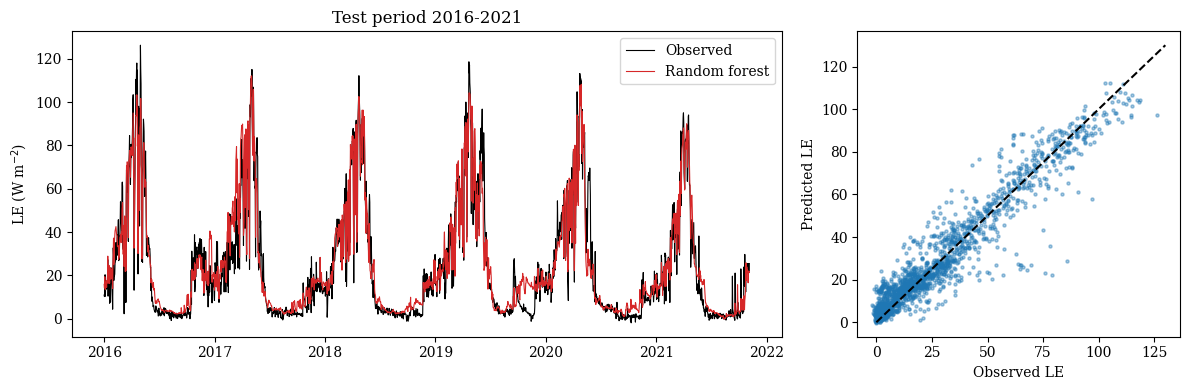

In [3]:
def nse(obs, sim):
    return 1 - np.sum((obs - sim) ** 2) / np.sum((obs - obs.mean()) ** 2)

rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, max_features=0.5, n_jobs=-1, random_state=0)
rf.fit(train[features], train['LE'])
pred = pd.Series(rf.predict(test[features]), index=test.index)
print(f"Test R2 = {r2_score(test['LE'], pred):.3f}, RMSE = {np.sqrt(mean_squared_error(test['LE'], pred)):.1f} W m-2, NSE = {nse(test['LE'].values, pred.values):.3f}")
pred_train = rf.predict(train[features])
print(f"Train R2 = {r2_score(train['LE'], pred_train):.3f}  (much higher than test = some overfitting, which is normal for forests)")

fig, axs = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [2.2, 1]})
axs[0].plot(test.index, test['LE'], 'k', lw=0.8, label='Observed'); axs[0].plot(pred.index, pred, 'tab:red', lw=0.8, label='Random forest')
axs[0].set_ylabel('LE (W m$^{-2}$)'); axs[0].legend(); axs[0].set_title('Test period 2016-2021')
axs[1].scatter(test['LE'], pred, s=5, alpha=0.4); lim = [0, 130]; axs[1].plot(lim, lim, 'k--'); axs[1].set_xlabel('Observed LE'); axs[1].set_ylabel('Predicted LE'); plt.tight_layout()

## **Step 2: Which inputs matter?**

Permutation importance shuffles one feature at a time in the *test* set and measures how much skill is lost. It is more honest than the built-in impurity importance, which favors continuous features with many split points.

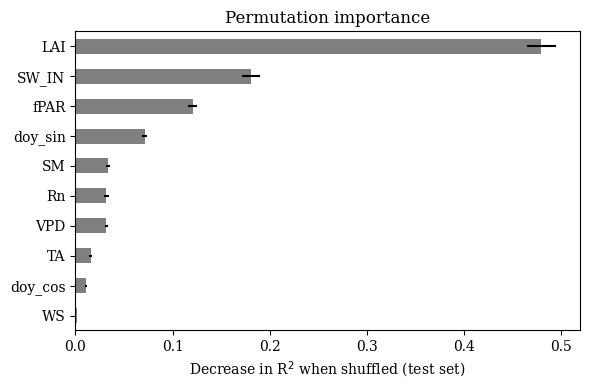

In [4]:
pi = permutation_importance(rf, test[features], test['LE'], n_repeats=10, random_state=0, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=features).sort_values()
fig, ax = plt.subplots(figsize=(6, 4)); imp.plot.barh(ax=ax, xerr=pd.Series(pi.importances_std, index=features)[imp.index], color='tab:grey')
ax.set_xlabel('Decrease in R$^2$ when shuffled (test set)'); ax.set_title('Permutation importance'); plt.tight_layout()

## **Step 3: What has the model learned about each driver?**

Partial dependence shows the average prediction as one feature is varied with the others held at their observed values.

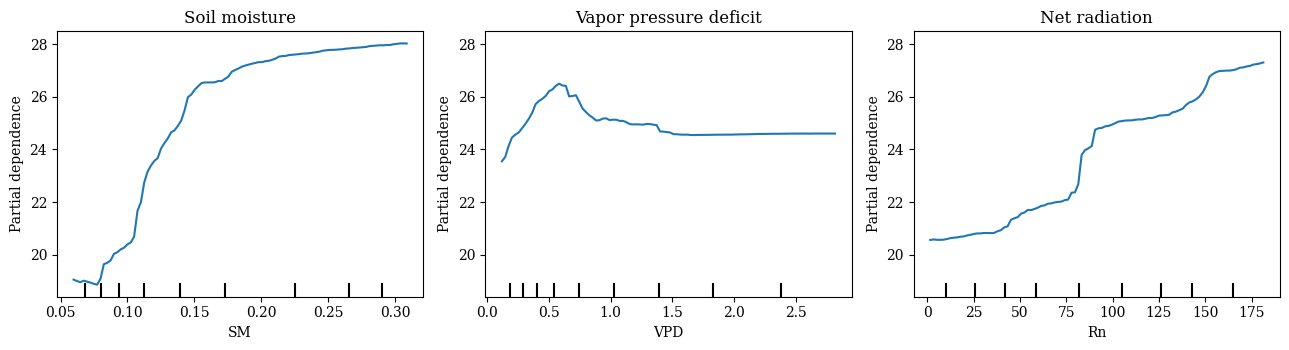

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
PartialDependenceDisplay.from_estimator(rf, train[features], ['SM', 'VPD', 'Rn'], ax=ax, kind='average')
ax[0].set_title('Soil moisture'); ax[1].set_title('Vapor pressure deficit'); ax[2].set_title('Net radiation'); plt.tight_layout()

**What to check.** LE should increase with net radiation, increase with soil moisture up to a plateau, and respond to
VPD in a way that depends on water availability (at this site, high VPD coincides with the dry summer, so the curve
falls). If the shape is physically reasonable, the model is capturing the controls rather than the calendar.

## **Step 4: Physical limits and extrapolation**

In [6]:
avail = (test['Rn'] - test['G']).values
viol = (pred.values > avail + 10).mean() * 100
print(f'Predictions exceeding available energy (Rn - G + 10 W m-2): {viol:.1f}% of test days')

# extrapolation test: train only on the cooler 80% of days, test on the hottest 20%
q = train['TA'].quantile(0.8)
rf_cool = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, max_features=0.5, n_jobs=-1, random_state=0).fit(train.loc[train['TA'] <= q, features], train.loc[train['TA'] <= q, 'LE'])
hot = test[test['TA'] > q]
p_hot = rf_cool.predict(hot[features]); p_hot_full = rf.predict(hot[features])
print(f'Hottest test days (TA > {q:.1f} C, n = {len(hot)}):')
print(f'  RMSE with full training     = {np.sqrt(np.mean((hot["LE"].values - p_hot_full) ** 2)):.1f} W m-2')
print(f'  RMSE trained on cool days   = {np.sqrt(np.mean((hot["LE"].values - p_hot) ** 2)):.1f} W m-2  <- extrapolation')

Predictions exceeding available energy (Rn - G + 10 W m-2): 2.6% of test days


Hottest test days (TA > 22.5 C, n = 517):
  RMSE with full training     = 7.7 W m-2
  RMSE trained on cool days   = 7.9 W m-2  <- extrapolation


Tree models cannot predict outside the range of targets they have seen; they extrapolate flat. That is harmless when
tomorrow looks like the training years and dangerous under a warming climate, which is the argument for building physics
into the model. The next tutorial does exactly that.

## **Exercises**

**Exercise 1.** Remove `doy_sin` and `doy_cos` from the features. How much skill is lost? What does that tell you about how much the model relies on the calendar rather than on physical drivers?

**Exercise 2.** Replace the time-based split with `sklearn.model_selection.train_test_split(shuffle=True)`. Report the test R$^2$ and explain why it is higher and why it is misleading.

**Exercise 3.** Train a `GradientBoostingRegressor` or `HistGradientBoostingRegressor` with default settings and compare test NSE with the random forest.

**Exercise 4.** Convert LE to ET (mm/day) and compute the test-period annual ET bias. Is a model with a good R$^2$ automatically good at annual totals?

## **References**

- Breiman, L. (2001). Random forests. *Machine Learning*, 45, 5-32.
- Tramontana, G., et al. (2016). Predicting carbon dioxide and energy fluxes across global FLUXNET sites with regression algorithms. *Biogeosciences*, 13, 4291-4313.
- Reichstein, M., et al. (2019). Deep learning and process understanding for data-driven Earth system science. *Nature*, 566, 195-204.